<a href="https://colab.research.google.com/github/seungmei/QNS/blob/main/PTCDA%2BFe_huckel_theory_simulation_260521.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PTCDA + Fe Huckel Model: HOMO Peak Shift Mechanism

- Mechanism-only toy model.
- Goal: explain why the PTCDA-derived HOMO dI/dV peak shifts to lower sample bias when more Fe atoms bind near the end carbonyl groups.

Kept physics:

1. Fe-O hybridization: an effective Fe d-like site couples to carbonyl O through beta_Fe_O.
2. Local electrostatic stabilization: Fe lowers nearby PTCDA on-site energies through a distance-decaying potential.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Compact publication style: closed frame, inward ticks, readable fonts.
plt.rcParams.update({
    'figure.dpi':        110,
    'savefig.dpi':       300,
    'font.family':       'sans-serif',
    'font.size':         12,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    12,
    'axes.linewidth':    1.3,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
    'xtick.major.size':  5,
    'ytick.major.size':  5,
    'xtick.minor.size':  3,
    'ytick.minor.size':  3,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.frameon':    True,
    'legend.framealpha': 1.0,
    'legend.fontsize':   10,
    'lines.linewidth':   2.0,
    'lines.markersize':  6,
})

def origin_style(ax, minor=True):
    """Apply inward-tick / closed-frame look to a single Axes."""
    ax.tick_params(which='both', direction='in', top=True, right=True)
    if minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    for sp in ax.spines.values():
        sp.set_linewidth(1.3)
    return ax

np.set_printoptions(precision=4, suppress=True)


## 1. Huckel and LDOS functions

build AO Hamiltonian -> diagonalize -> broaden each MO with a Lorentzian.

$$H_{ii}=\alpha_i, \qquad H_{ij}=\beta_{ij}\quad \text{if sites i and j are bonded.}$$

$$H C = C E, \qquad dI/dV(V) \propto \sum_n w_n L(V-V_n;\gamma).$$

In [2]:
def make_hamiltonian(n_sites, onsite, bonds):
    H = np.zeros((n_sites, n_sites))
    H[np.arange(n_sites), np.arange(n_sites)] = onsite
    for i, j, beta in bonds:
        H[i, j] = H[j, i] = beta
    return H


def solve_huckel(H):
    if not np.allclose(H, H.T, atol=1e-12):
        raise ValueError('Hamiltonian must be symmetric')
    return np.linalg.eigh(H)


def lorentzian(x, center, gamma):
    """L(x; c, g) = g / (pi * ((x-c)^2 + g^2))."""
    return gamma / (np.pi * ((x - center)**2 + gamma**2))


def normalize_peak(y):
    return np.asarray(y) / (np.nanmax(np.abs(y)) + 1e-15)


def broadened_spectrum(centers, V_axis, gamma, weights=None):
    """sum_n w_n L(V - V_n; gamma) -- delta-list to a continuous dI/dV."""
    centers = np.asarray(centers)
    if weights is None:
        weights = np.ones_like(centers)
    peaks = lorentzian(V_axis[None, :], centers[:, None], gamma)
    return np.sum(np.asarray(weights)[:, None] * peaks, axis=0)


## 2. Benzene sanity check

Engine validation against the analytic Hückel result $\{-2,-1,-1,+1,+1,+2\}\,|\beta|$
including the $C_6$-symmetry doubly-degenerate $\pm 1$ levels.

- expected energy for benzene
$$E_k = \alpha + 2\beta \cos\left(\frac{2\pi k}{N}\right) \quad (k = 0, 1, \dots, N-1)$$
  - alpha: Coulomb Integral/On-site energy(Let's set this to 0)
  - beta: Resonance Integral/Hopping energy

benzene energies / |beta| : [-2.0, -1.0, -1.0, 1.0, 1.0, 2.0]
expected                  : [-2.0, -1.0, -1.0, 1.0, 1.0, 2.0]
max error                 : 4.44e-16


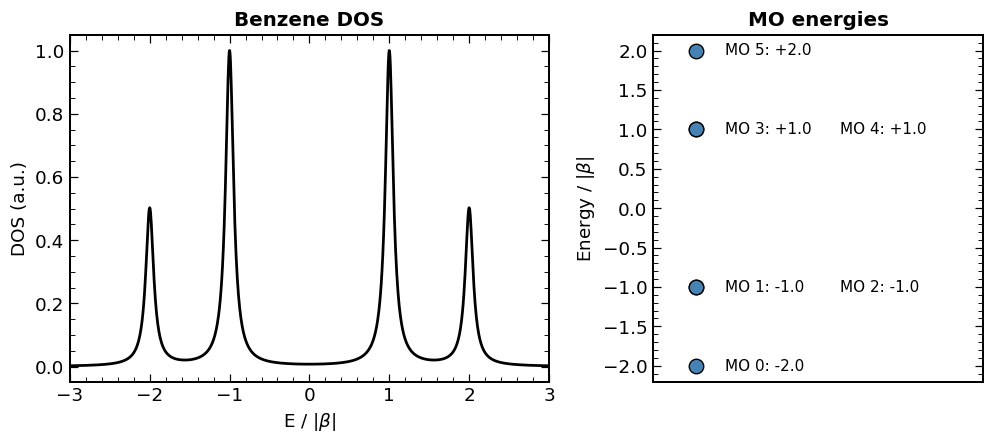

In [3]:
def build_benzene(alpha=0.0, beta=-1.0):
    onsite = [alpha] * 6
    bonds = [(i, (i + 1) % 6, beta) for i in range(6)]
    H = make_hamiltonian(6, onsite, bonds)
    E, C = solve_huckel(H)
    return H, E, C


H_benz, E_benz, _ = build_benzene()
expected = np.array([-2, -1, -1, 1, 1, 2], dtype=float)
err = np.max(np.abs(E_benz - expected))
assert err < 1e-10
print(f'benzene energies / |beta| : {np.round(E_benz, 3).tolist()}')
print(f'expected                  : {expected.tolist()}')
print(f'max error                 : {err:.2e}')

V_benz = np.linspace(-3, 3, 1200)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2),
                         gridspec_kw={'width_ratios': [1.45, 1.0]})

# (left) total DOS + delta sticks
axes[0].plot(V_benz,
             normalize_peak(broadened_spectrum(E_benz, V_benz, gamma=0.06)),
             color='black', lw=1.8)
axes[0].set_xlabel(r'E / $|\beta|$')
axes[0].set_ylabel('DOS (a.u.)')
axes[0].set_title('Benzene DOS')
axes[0].set_xlim(-3, 3)
origin_style(axes[0])

# (right figure) MO ladder
axes[1].scatter(np.zeros_like(E_benz), E_benz, s=90, color='steelblue',
                edgecolor='black', linewidth=0.9, zorder=3)

# overlapping energy level
energy_counts = {}

for idx, e in enumerate(E_benz):
    e_rounded = round(e, 3)
    count = energy_counts.get(e_rounded, 0)

    # 같은 에너지일 경우 x좌표를 0.4만큼 오른쪽으로 밀기
    x_pos = 0.10 + (count * 0.4)

    axes[1].text(x_pos, e, f'MO {idx}: {e:+.1f}', va='center', fontsize=10)
    # 해당 에너지 레벨의 카운트 증가
    energy_counts[e_rounded] = count + 1

axes[1].set_xlim(-0.15, 1.0)
axes[1].set_xticks([])
axes[1].set_ylabel(r'Energy / $|\beta|$')
axes[1].set_title('MO energies')
origin_style(axes[1], minor=False)
axes[1].tick_params(axis='x', which='both', bottom=False, top=False)
plt.tight_layout()
plt.show()

## 3. PTCDA + Fe Huckel matrix (bridge-O excluded)

- PTCDA: **28 pi sites**: 20 perylene C + 4 carbonyl C + 4 carbonyl O. (bridge O x)

- pi-electron: 28 (1e- for each site)

- HOMO index = 13, LUMO index = 14.

- Fe model (1 effective d-site, 1 e- each):
Fe enters as a single d-like orbital that couples to one carbonyl O via beta_Fe-O.

$N_e = 28 + n_\mathrm{Fe}$

- Hamiltonian structure (PTCDA + Fe)
$$
H \;=\;
\begin{pmatrix}
 H_\mathrm{PTCDA}\;(28\times28) & V\;(28\times n_\mathrm{Fe}) \\
 V^{\top}\;(n_\mathrm{Fe}\times28) & H_\mathrm{Fe}\;(n_\mathrm{Fe}\times n_\mathrm{Fe})
\end{pmatrix}
$$
with $V_{ij}=\beta_\mathrm{Fe\text{-}O}$ only on (carbonyl-O, Fe) pairs and 0 elsewhere
- ??ignore Fe-Fe direct coupling??


In [4]:
# Huckel parameters (eV).  Convention: beta_CC = -2.5 eV; |alpha| slightly > |beta_CC|.
# All values are effective tight-binding, NOT ab initio.
PARAMS = {
    # On-site (alpha): more negative -> deeper / more electronegative.
    'alpha_c':           -3.00,    # C 2p, |alpha| ~ |beta_CC| + a little
    'alpha_o_carbonyl':  -4.00,    # carbonyl O, deeper than C
    'alpha_fe':          -2.20,    # Fe d-like, above C

    # Hopping (beta): negative -> bonding overlap.
    'beta_cc':           -2.50,    # perylene C-C pi
    'beta_co_double':    -2.30,    # C=O carbonyl
    'beta_fe_o':         -1.00,    # Fe(3d)-O(2p) coordination

    # Fe-induced local electrostatics (Madelung-like attractive well on PTCDA).
    'electrostatic_shift': -0.30,
    'electrostatic_decay':  3.00,

    # dI/dV broadening
    'gamma':               0.08,
}

# Geometry constants (Å)
A_CC   = 1.40
A_FE_O = 2.00

# Pi-electron bookkeeping (28 pi sites; bridge O is NOT in the pi basis).
N_PTCDA_SITES     = 28
N_PTCDA_ELECTRONS = 28           # 24 C (each 1e-) + 4 carbonyl O (each 1e-)
N_FE_ELECTRONS    = 1            # each Fe contributes 1 e- to the model
HOMO_INDEX        = N_PTCDA_ELECTRONS // 2 - 1   # 13
LUMO_INDEX        = HOMO_INDEX + 1               # 14
CARBONYL_O        = [24, 25, 26, 27]


def params_with(update=None):
    p = dict(PARAMS)
    if update:
        p.update(update)
    return p


def build_ptcda_geometry(params=None):
    """28-site PTCDA: 20 perylene C + 4 carbonyl C + 4 carbonyl O.
    Indices 0..19 = perylene, 20..23 = Can, 24..27 = Oco."""
    a = A_CC
    sx = a * np.sqrt(3) / 2
    naph = np.array([
        [0.0, a/2], [0.0, -a/2],
        [sx, a], [2*sx, a/2], [2*sx, -a/2], [sx, -a],
        [-sx, a], [-2*sx, a/2], [-2*sx, -a/2], [-sx, -a],
    ])
    coords = np.vstack([
        naph + [0.0,  1.5*a], naph + [0.0, -1.5*a],
        [[ sx,  3.5*a], [-sx,  3.5*a], [ sx, -3.5*a], [-sx, -3.5*a]],
        [[ 2*sx, 4.0*a], [-2*sx, 4.0*a], [2*sx, -4.0*a], [-2*sx, -4.0*a]],
    ])
    labels = ['C']*20 + ['Can']*4 + ['Oco']*4

    p = params_with(params)
    b_cc, b_co_d = p['beta_cc'], p['beta_co_double']
    naph_internal = [(0,1),(0,2),(0,6),(1,5),(1,9),
                     (2,3),(3,4),(4,5),(6,7),(7,8),(8,9)]
    bonds = []
    for i, j in naph_internal:
        bonds += [(i, j, b_cc), (10+i, 10+j, b_cc)]
    bonds += [(5, 12, b_cc), (9, 16, b_cc),
              (2, 20, b_cc), (6, 21, b_cc), (15, 22, b_cc), (19, 23, b_cc),
              (20, 24, b_co_d), (21, 25, b_co_d),
              (22, 26, b_co_d), (23, 27, b_co_d)]
    coords = coords[:, [1, 0]]   # +x = long molecular axis, +y = short axis
    return coords, labels, bonds


def fe_binding_sites(params=None):
    """Each Fe sits outward from one carbonyl O at distance A_FE_O."""
    coords, _, _ = build_ptcda_geometry(params)
    sites = []
    for ox_idx in CARBONYL_O:
        ox = coords[ox_idx]
        outward = ox / (np.linalg.norm(ox) + 1e-12)
        sites.append((ox + A_FE_O * outward, ox_idx))
    return sites


# Bridge -O- (anhydride): VISUALIZATION ONLY, not in the 28-site basis.
BRIDGE_O_TO_CAN = {0: (20, 21), 1: (22, 23)}


def bridge_o_positions():
    a = A_CC
    return np.array([[ 4 * a, 0.0],
                     [-4 * a, 0.0]])


def _draw_bridge_o(ax, params=None, z=None, scale=1.0, alpha=0.55,
                   label_atoms=False):
    coords, _, _ = build_ptcda_geometry(params)
    br = bridge_o_positions()
    color_atom, color_bond = '#d99', '0.55'

    for br_idx, (ca_a, ca_b) in BRIDGE_O_TO_CAN.items():
        bx, by = br[br_idx]
        for ca in (ca_a, ca_b):
            cx, cy = coords[ca]
            if z is None:
                ax.plot([cx, bx], [cy, by], color=color_bond,
                        lw=1.0, ls='--', alpha=alpha, zorder=0)
            else:
                ax.plot([cx, bx], [cy, by], [z, z], color=color_bond,
                        lw=1.0, ls='--', alpha=alpha, zorder=0)

    if z is None:
        ax.scatter(br[:, 0], br[:, 1], s=70 * scale, c=color_atom,
                   marker='o', edgecolor='gray', linewidth=0.8,
                   alpha=alpha, zorder=2)
        if label_atoms:
            for x, y in br:
                ax.annotate('O*  (bridge,\nnot in basis)',
                            xy=(x, y), xytext=(8, 0),
                            textcoords='offset points',
                            fontsize=8, color='gray', alpha=0.85,
                            va='center')
    else:
        ax.scatter(br[:, 0], br[:, 1], [z, z], s=40 * scale, c=color_atom,
                   edgecolor='gray', linewidth=0.6, alpha=alpha,
                   depthshade=False)
    return br


def build_ptcda_fe_hamiltonian(n_fe=0, params=None,
                               include_hybridization=True,
                               include_electrostatics=True):
    if not 0 <= n_fe <= 4:
        raise ValueError('n_fe must be 0..4')
    p = params_with(params)
    coords, labels, bonds = build_ptcda_geometry(params)
    n_p = len(coords)
    fe_sites = fe_binding_sites(params)[:n_fe]

    on_map = {'C': p['alpha_c'], 'Can': p['alpha_c'],
              'Oco': p['alpha_o_carbonyl']}
    onsite = np.array([on_map[t] for t in labels]
                      + [p['alpha_fe']] * n_fe)

    if include_electrostatics and n_fe:
        for fe_xy, _ in fe_sites:
            d = np.linalg.norm(coords - fe_xy, axis=1)
            onsite[:n_p] += p['electrostatic_shift'] * np.exp(
                -d / p['electrostatic_decay'])

    all_bonds = list(bonds)
    fe_coords = []
    for k, (fe_xy, ox_idx) in enumerate(fe_sites):
        if include_hybridization:
            all_bonds.append((ox_idx, n_p + k, p['beta_fe_o']))
        fe_coords.append(fe_xy)

    H = make_hamiltonian(n_p + n_fe, onsite, all_bonds)
    all_coords = (np.vstack([coords, np.array(fe_coords)])
                  if fe_coords else coords.copy())
    return H, all_coords, labels + ['Fe'] * n_fe


def solve_ptcda_fe(n_fe=0, params=None,
                   include_hybridization=True, include_electrostatics=True):
    H, coords, labels = build_ptcda_fe_hamiltonian(
        n_fe=n_fe, params=params,
        include_hybridization=include_hybridization,
        include_electrostatics=include_electrostatics)
    E, C = solve_huckel(H)
    return {'H': H, 'coords': coords, 'labels': labels,
            'energies': E, 'orbitals': C, 'n_fe': n_fe,
            'params': params_with(params)}


def combined_filling(n_fe):
    """Total electron count and combined-system HOMO/LUMO indices.
    PTCDA contributes 28 e-, each Fe contributes 1 e-."""
    n_tot = N_PTCDA_ELECTRONS + n_fe * N_FE_ELECTRONS
    n_full = n_tot // 2
    # If odd, top orbital is singly occupied (SOMO). Treat SOMO as HOMO.
    homo = n_full - 1 if n_tot % 2 == 0 else n_full
    lumo = homo + 1
    return {'n_tot_e': n_tot, 'homo': homo, 'lumo': lumo,
            'open_shell': bool(n_tot % 2)}


def model_fermi_reference(params=None):
    s = solve_ptcda_fe(0, params=params)
    return 0.5 * (s['energies'][HOMO_INDEX] + s['energies'][LUMO_INDEX])


def energy_to_bias(E, params=None):
    return np.asarray(E) - model_fermi_reference(params)


sol0 = solve_ptcda_fe(0)
E_HOMO = sol0['energies'][HOMO_INDEX]
E_LUMO = sol0['energies'][LUMO_INDEX]
gap_signed = E_HOMO - E_LUMO            # user spec: HOMO - LUMO (negative)

print(f"PTCDA sites: {len(sol0['labels'])}  "
      f"({dict((x, sol0['labels'].count(x)) for x in sorted(set(sol0['labels'])))})")
print(f"pi electrons in PTCDA: {N_PTCDA_ELECTRONS}   "
      f"electrons per Fe: {N_FE_ELECTRONS}")
print(f"HOMO / LUMO index (free PTCDA): {HOMO_INDEX} / {LUMO_INDEX}")
print()
print(f"E_HOMO              = {E_HOMO:+.4f} eV")
print(f"E_LUMO              = {E_LUMO:+.4f} eV")
print(f"HOMO - LUMO gap     = {gap_signed:+.4f} eV    (|gap| = {abs(gap_signed):.4f} eV)")
print(f"E_HOMO  (vs E_F)    = {energy_to_bias(E_HOMO):+.4f} eV")
print(f"E_LUMO  (vs E_F)    = {energy_to_bias(E_LUMO):+.4f} eV")
print()
print("combined-system filling (PTCDA pi electrons + n_Fe x 1 e-)")
print("  n_Fe   total e-   HOMO idx   LUMO idx   open shell?")
for n_fe in range(5):
    f = combined_filling(n_fe)
    print(f"  {n_fe:>4d}   {f['n_tot_e']:>8d}   {f['homo']:>8d}   "
          f"{f['lumo']:>8d}   {str(f['open_shell']):>11s}")


PTCDA sites: 28  ({'C': 20, 'Can': 4, 'Oco': 4})
pi electrons in PTCDA: 28   electrons per Fe: 1
HOMO / LUMO index (free PTCDA): 13 / 14

E_HOMO              = -3.9124 eV
E_LUMO              = -2.7393 eV
HOMO - LUMO gap     = -1.1731 eV    (|gap| = 1.1731 eV)
E_HOMO  (vs E_F)    = -0.5865 eV
E_LUMO  (vs E_F)    = +0.5865 eV

combined-system filling (PTCDA pi electrons + n_Fe x 1 e-)
  n_Fe   total e-   HOMO idx   LUMO idx   open shell?
     0         28         13         14         False
     1         29         14         15          True
     2         30         14         15         False
     3         31         15         16          True
     4         32         15         16         False


### Atom-to-index map

Before building $H$, the figure below labels every PTCDA atom with its row/column index in the 28-site basis. Fe atoms occupy indices $28, 29, \ldots, 28 + n_\mathrm{Fe} - 1$ in the order

$$\text{Fe}_0 \to \text{O}_{24},\quad \text{Fe}_1 \to \text{O}_{25},\quad \text{Fe}_2 \to \text{O}_{26},\quad \text{Fe}_3 \to \text{O}_{27}.$$

That binding order means n_Fe = 2 places **both Fe on the top anhydride end**, n_Fe = 3 adds the bottom-right corner, and n_Fe = 4 fills all four. This choice is documented here so the matrix audit (Section 4.5) can refer to it without ambiguity.


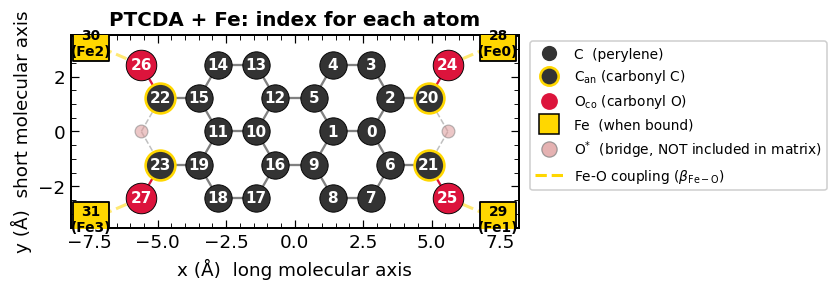

In [5]:
def plot_atom_index_map(params=None, figsize=(7.8, 7.2)):
    """Show every PTCDA atom and its row/column index in the 28-site basis,
    plus the 4 Fe binding positions (indices 28..31 when all are present)."""
    coords, labels, bonds = build_ptcda_geometry(params)
    fe_sites = fe_binding_sites(params)

    fig, ax = plt.subplots(figsize=figsize)

    # bonds
    for (i, j, _) in bonds:
        col = 'crimson' if 'Oco' in (labels[i], labels[j]) else '0.5'
        ax.plot([coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color=col, lw=1.5, zorder=1)

    # Bridge -O- (visualization only, not in basis)
    _draw_bridge_o(ax, label_atoms=False)

    # PTCDA atoms with index labels
    style = {'C':   dict(c='#333', s=320),
             'Can': dict(c='#333', s=380),
             'Oco': dict(c='crimson', s=400)}
    ec_of = {'C': 'black', 'Can': 'gold', 'Oco': 'black'}
    lw_of = {'C': 0.6,    'Can': 1.7,    'Oco': 0.6}

    for k, (R, lab) in enumerate(zip(coords, labels)):
        ax.scatter(R[0], R[1], edgecolor=ec_of[lab], linewidth=lw_of[lab],
                   zorder=3, **style[lab])
        ax.annotate(str(k), xy=(R[0], R[1]), ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white', zorder=4)

    # Fe positions
    for k, (fe_xy, ox_idx) in enumerate(fe_sites):
        ax.plot([coords[ox_idx, 0], fe_xy[0]],
                [coords[ox_idx, 1], fe_xy[1]],
                color='gold', lw=2.0, ls='--', alpha=0.55, zorder=2)
        ax.scatter(fe_xy[0], fe_xy[1], s=540, c='gold', marker='s',
                   edgecolor='black', linewidth=1.2, zorder=3)
        ax.annotate(f'{N_PTCDA_SITES + k}\n(Fe{k})',
                    xy=(fe_xy[0], fe_xy[1]), ha='center', va='center',
                    fontsize=9, fontweight='bold', color='black', zorder=4)

    # legend
    from matplotlib.lines import Line2D

    leg = [
        Line2D([0], [0], marker='o', color='w', mfc='#333', ms=11,
               label=r'C  (perylene)'),

        Line2D([0], [0], marker='o', color='w', mfc='#333', mec='gold',
               mew=1.7, ms=12,
               label=r'C$_{\mathrm{an}}$ (carbonyl C)'),

        Line2D([0], [0], marker='o', color='w', mfc='crimson', ms=12,
               label=r'O$_{\mathrm{co}}$ (carbonyl O)'),

        Line2D([0], [0], marker='s', color='w', mfc='gold', mec='black',
               mew=1.0, ms=13,
               label=r'Fe  (when bound)'),

        Line2D([0], [0], marker='o', color='w', mfc='#d99', mec='gray',
               mew=0.8, ms=10, alpha=0.75,
               label=r'O$^{*}$  (bridge, NOT included in matrix)'),

        Line2D([0], [0], color='gold', lw=2.0, ls='--',
               label=r'Fe-O coupling ($\beta_{\mathrm{Fe-O}}$)'),
    ]

    ax.legend(handles=leg, loc='upper left', fontsize=9, framealpha=0.95,
              bbox_to_anchor=(1.01, 1.0))

    ax.set_aspect('equal')
    ax.set_xlabel('x (Å)  long molecular axis')
    ax.set_ylabel('y (Å)  short molecular axis')
    ax.set_title('PTCDA + Fe: index for each atom')
    origin_style(ax, minor=False)
    plt.tight_layout()
    plt.show()


plot_atom_index_map()

## 4. Block-matrix view: H = [[H_PTCDA, V], [V^T, H_Fe]]

$n_\mathrm{Fe}\in\{0,1,2,3,4\}$

$$
H \;=\;
\begin{pmatrix}
H_\mathrm{PTCDA}\;(28\times28) & V\;(28\times n_\mathrm{Fe}) \\
V^{\top}\;(n_\mathrm{Fe}\times28) & H_\mathrm{Fe}\;(n_\mathrm{Fe}\times n_\mathrm{Fe})
\end{pmatrix}
$$

where $V_{ij}=\beta_\mathrm{Fe\text{-}O}$ only on (carbonyl-O, Fe) entries and
$H_\mathrm{Fe}=\mathrm{diag}(\alpha_\mathrm{Fe})$.


n_Fe = 0   H shape = (28, 28)   blocks: H_PTCDA (28, 28), V (28, 0), H_Fe (0, 0)
  H_PTCDA diag (eV): [-3. -3. -3. -3. -3. -3. -3. -3. -3. -3. -3. -3. -3. -3. -3. -3. -3. -3.
 -3. -3. -3. -3. -3. -3. -4. -4. -4. -4.]

n_Fe = 4   H shape = (32, 32)   blocks: H_PTCDA (28, 28), V (28, 4), H_Fe (4, 4)
  H_PTCDA diag (eV): [-3.108 -3.087 -3.124 -3.105 -3.083 -3.081 -3.124 -3.105 -3.083 -3.081
 -3.087 -3.108 -3.081 -3.083 -3.105 -3.124 -3.081 -3.083 -3.105 -3.124
 -3.165 -3.165 -3.165 -3.165 -4.202 -4.202 -4.202 -4.202]
  V nonzero rows = [24, 25, 26, 27], value = -1.00 eV
  H_Fe diag = [-2.2, -2.2, -2.2, -2.2]



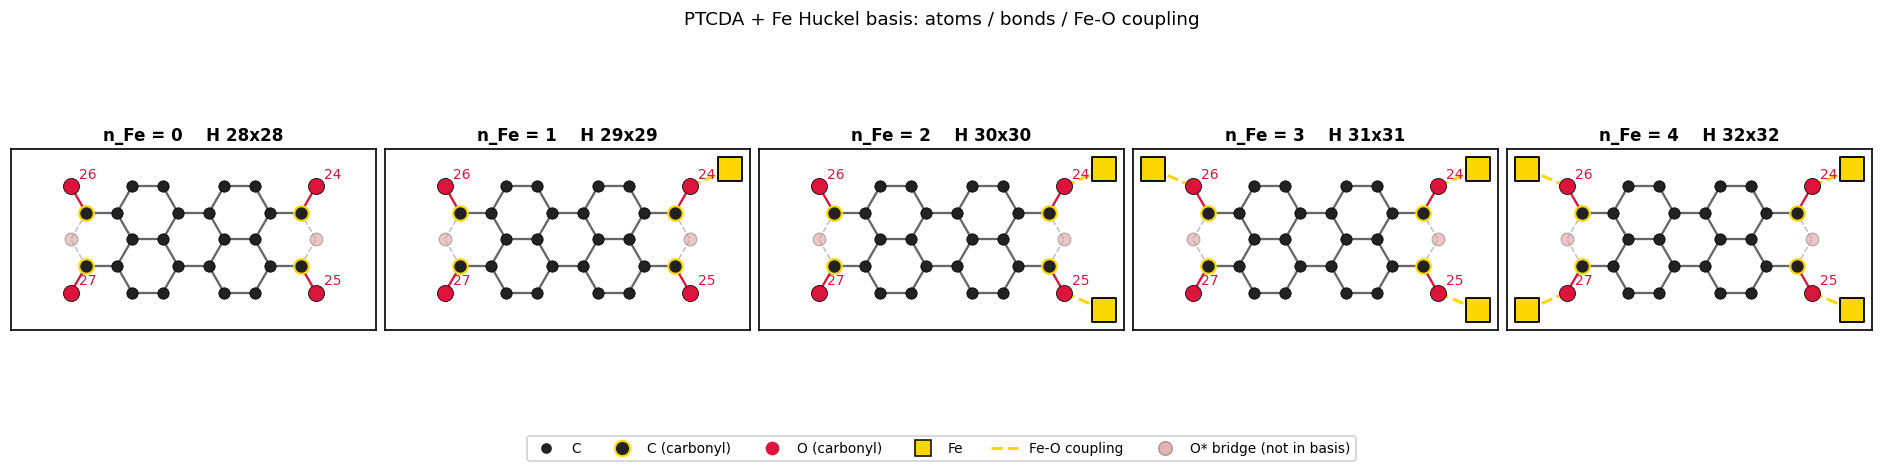

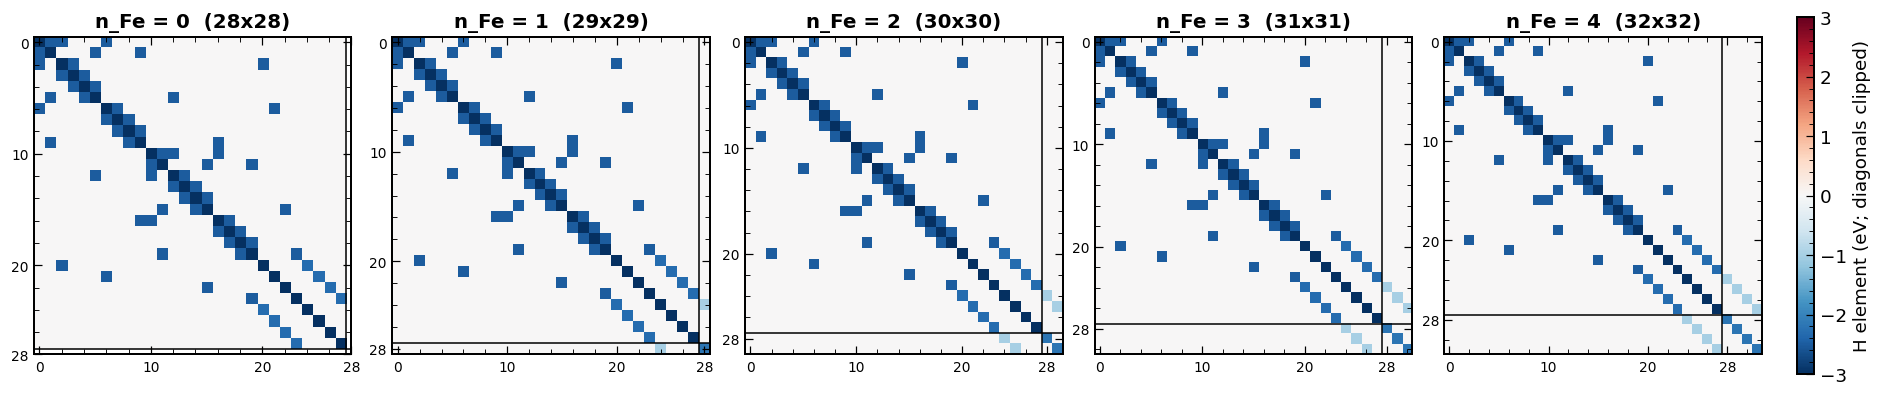

In [6]:
def split_blocks(H, n_ptcda=N_PTCDA_SITES):
    return (H[:n_ptcda, :n_ptcda],
            H[:n_ptcda, n_ptcda:],
            H[n_ptcda:, n_ptcda:])


def print_block_summary(n_fe, params=None):
    sol = solve_ptcda_fe(n_fe, params=params)
    H_p, V, H_f = split_blocks(sol['H'])
    print(f'n_Fe = {n_fe}   H shape = {sol["H"].shape}   '
          f'blocks: H_PTCDA {H_p.shape}, V {V.shape}, H_Fe {H_f.shape}')
    print('  H_PTCDA diag (eV):', np.round(np.diag(H_p), 3))
    if n_fe:
        nz = np.where(np.any(np.abs(V) > 1e-12, axis=1))[0]
        print(f'  V nonzero rows = {nz.tolist()}, value = {V[nz[0], 0]:.2f} eV')
        print(f'  H_Fe diag = {np.diag(H_f).round(3).tolist()}')
    print()


def plot_block_matrix_grid(n_fe_list=(0, 1, 2, 3, 4), params=None):
    mats = [solve_ptcda_fe(n, params=params)['H'] for n in n_fe_list]
    vmax = max(abs(PARAMS['beta_cc']), abs(PARAMS['beta_co_double']), 1.0) + 0.5

    fig, axes = plt.subplots(1, len(n_fe_list),
                             figsize=(3.4 * len(n_fe_list), 3.9),
                             constrained_layout=True)
    for ax, n_fe, H in zip(axes, n_fe_list, mats):
        im = ax.imshow(H, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                       interpolation='nearest')
        ax.axhline(N_PTCDA_SITES - 0.5, color='black', lw=1.0)
        ax.axvline(N_PTCDA_SITES - 0.5, color='black', lw=1.0)
        ax.set_title(f'n_Fe = {n_fe}  ({H.shape[0]}x{H.shape[0]})')
        ax.set_xticks([0, 10, 20, N_PTCDA_SITES])
        ax.set_yticks([0, 10, 20, N_PTCDA_SITES])
        ax.tick_params(labelsize=9)
    cb = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
    cb.set_label('H element (eV; diagonals clipped)')
    plt.show()


_ATOM_STYLE = {
    'C':   dict(c='#222', s=55, marker='o', label='C (perylene)'),
    'Can': dict(c='#222', s=90, marker='o', edgecolor='gold',
                linewidth=1.4, label='C (carbonyl)'),
    'Oco': dict(c='crimson', s=110, marker='o', label='O (carbonyl)'),
    'Fe':  dict(c='gold',    s=230, marker='s', edgecolor='black',
                linewidth=1.2, label='Fe'),
}


def plot_ptcda_fe_structure_grid(n_fe_list=(0, 1, 2, 3, 4), params=None):
    coords, labels, bonds = build_ptcda_geometry(params)
    fe_sites = fe_binding_sites(params)

    fig, axes = plt.subplots(1, len(n_fe_list),
                             figsize=(3.4 * len(n_fe_list), 4.0),
                             constrained_layout=True)

    br = bridge_o_positions()
    all_x = np.concatenate([coords[:, 0], [s[0][0] for s in fe_sites],
                            br[:, 0]])
    all_y = np.concatenate([coords[:, 1], [s[0][1] for s in fe_sites],
                            br[:, 1]])
    xlim = (all_x.min() - 0.9, all_x.max() + 0.9)
    ylim = (all_y.min() - 0.9, all_y.max() + 0.9)

    for ax, n_fe in zip(axes, n_fe_list):
        _draw_bridge_o(ax, params=params)
        for (i, j, _b) in bonds:
            col = 'crimson' if 'Oco' in (labels[i], labels[j]) else '0.4'
            ax.plot([coords[i, 0], coords[j, 0]],
                    [coords[i, 1], coords[j, 1]],
                    color=col, lw=1.5, zorder=1)

        for kind in ('C', 'Can', 'Oco'):
            idx = [k for k, lab in enumerate(labels) if lab == kind]
            s = dict(_ATOM_STYLE[kind])
            ec = s.pop('edgecolor', 'black'); lw = s.pop('linewidth', 0.5)
            s.pop('label')
            ax.scatter(coords[idx, 0], coords[idx, 1],
                       edgecolor=ec, linewidth=lw, zorder=3, **s)

        for k in range(n_fe):
            fe_xy, ox_idx = fe_sites[k]
            ox = coords[ox_idx]
            ax.plot([ox[0], fe_xy[0]], [ox[1], fe_xy[1]],
                    color='gold', lw=2.0, ls='--', zorder=2)
            s = dict(_ATOM_STYLE['Fe'])
            ec = s.pop('edgecolor'); lw = s.pop('linewidth'); s.pop('label')
            ax.scatter([fe_xy[0]], [fe_xy[1]], edgecolor=ec, linewidth=lw,
                       zorder=4, **s)

        for ox_idx in CARBONYL_O:
            ox = coords[ox_idx]
            ax.annotate(str(ox_idx), xy=(ox[0], ox[1]),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=9, color='crimson')

        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_linewidth(1.1)
        ax.set_title(f'n_Fe = {n_fe}    H '
                     f'{N_PTCDA_SITES + n_fe}x{N_PTCDA_SITES + n_fe}',
                     fontsize=11)

    from matplotlib.lines import Line2D
    leg = [
        Line2D([0],[0], marker='o', color='w', mfc='#222', ms=8, label='C'),
        Line2D([0],[0], marker='o', color='w', mfc='#222', mec='gold',
               mew=1.4, ms=10, label='C (carbonyl)'),
        Line2D([0],[0], marker='o', color='w', mfc='crimson', ms=10,
               label='O (carbonyl)'),
        Line2D([0],[0], marker='s', color='w', mfc='gold', mec='black',
               mew=1.0, ms=11, label='Fe'),
        Line2D([0],[0], color='gold', lw=2.0, ls='--', label='Fe-O coupling'),
        Line2D([0],[0], marker='o', color='w', mfc='#d99', mec='gray',
               mew=0.8, ms=9, alpha=0.75,
               label='O* bridge (not in basis)'),
    ]
    # Single shared legend below the row of panels
    fig.legend(handles=leg, loc='lower center', ncol=6, fontsize=9,
               framealpha=0.95, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle('PTCDA + Fe Huckel basis: atoms / bonds / Fe-O coupling',
                 fontsize=12)
    plt.show()


# Print boundary cases only; visuals cover the rest.
for n in (0, 4):
    print_block_summary(n)
plot_ptcda_fe_structure_grid()
plot_block_matrix_grid()


## 5. HOMO-derived peak

Adding Fe enlarges the basis and changes MOs

In [7]:
def reference_orbital(label='HOMO', params=None):
    sol0 = solve_ptcda_fe(0, params=params)
    label = label.upper()
    idx = HOMO_INDEX if label == 'HOMO' else LUMO_INDEX
    return sol0['orbitals'][:, idx], sol0['energies'][idx], idx


def track_reference_orbital(label='HOMO', max_fe=4, params=None,
                            include_hybridization=True,
                            include_electrostatics=True):
    ref_vec, ref_energy, _ = reference_orbital(label, params=params)
    n_ref = len(ref_vec)
    rows = []
    for n_fe in range(max_fe + 1):
        sol = solve_ptcda_fe(n_fe, params=params,
                             include_hybridization=include_hybridization,
                             include_electrostatics=include_electrostatics)
        projection = sol['orbitals'][:n_ref, :].T @ ref_vec
        overlap = np.abs(projection)**2
        state = int(np.argmax(overlap))
        energy = float(sol['energies'][state])
        fe_weight = 0.0
        if sol['orbitals'].shape[0] > n_ref:
            fe_weight = float(np.sum(np.abs(sol['orbitals'][n_ref:, state])**2))
        rows.append({
            'n_fe': n_fe,
            'state': state,
            'energy': energy,
            'bias': float(energy_to_bias(energy, params=params)),
            'shift_V': float(energy_to_bias(energy, params=params) - energy_to_bias(ref_energy, params=params)),
            'ptcda_overlap': float(overlap[state]),
            'fe_weight': fe_weight,
        })
    return rows


def print_peak_table(label='HOMO', params=None):
    rows = track_reference_orbital(label, params=params)
    print(f'{label.upper()}-derived peak tracking')
    print('n_Fe  state   E(eV)      shift(eV)  energy(eV)  PTCDA overlap  Fe weight')
    for r in rows:
        print(f"{r['n_fe']:>4d}  {r['state']:>5d}  {r['bias']:>+9.4f}  {r['shift_V']:>+9.4f}"
              f"  {r['energy']:>+10.4f}     {r['ptcda_overlap']:>7.3f}     {r['fe_weight']:>7.3f}")
    return rows


homo_rows = print_peak_table('HOMO')

HOMO-derived peak tracking
n_Fe  state   E(eV)      shift(eV)  energy(eV)  PTCDA overlap  Fe weight
   0     13    -0.5865    +0.0000     -3.9124       1.000       0.000
   1     13    -0.6605    -0.0739     -3.9863       0.968       0.020
   2     13    -0.7355    -0.1489     -4.0613       0.934       0.039
   3     13    -0.8054    -0.2189     -4.1313       0.927       0.054
   4     13    -0.8784    -0.2919     -4.2043       0.918       0.069


## 6. PTCDA-projected dI/dV peak-shift figure


HOMO-derived peak positions
n_Fe   state   peak(E-E_F) eV   shift eV
   0      13          -0.5865    +0.0000
   1      13          -0.6605    -0.0739
   2      13          -0.7355    -0.1489
   3      13          -0.8054    -0.2189
   4      13          -0.8784    -0.2919


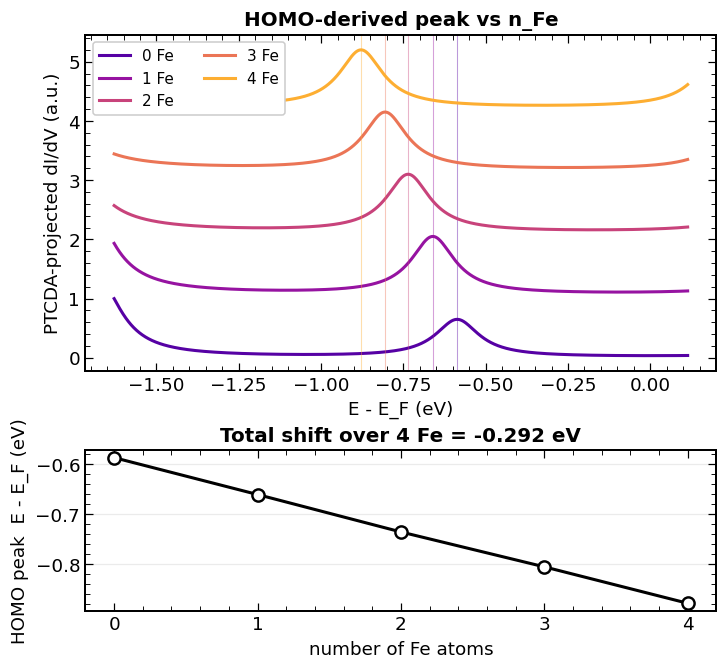

In [8]:
def ptcda_projection_weights(sol):
    return np.sum(np.abs(sol['orbitals'][:N_PTCDA_SITES, :])**2, axis=0)


def didv_spectrum(sol, V_axis, projection='ptcda'):
    centers = energy_to_bias(sol['energies'], params=sol['params'])
    weights = ptcda_projection_weights(sol) if projection == 'ptcda' else None
    return broadened_spectrum(centers, V_axis,
                              sol['params']['gamma'], weights=weights)


def plot_peak_shift_summary(label='HOMO', max_fe=4, params=None):
    rows = track_reference_orbital(label, max_fe=max_fe, params=params)
    V = np.linspace(min(r['bias'] for r in rows) - 0.75,
                    max(r['bias'] for r in rows) + 0.70, 2000)
    colors = plt.cm.plasma(np.linspace(0.15, 0.82, max_fe + 1))

    print(f'{label.upper()}-derived peak positions')
    print('n_Fe   state   peak(E-E_F) eV   shift eV')
    for r in rows:
        print(f"{r['n_fe']:>4d}   {r['state']:>5d}   "
              f"{r['bias']:>+14.4f}   {r['shift_V']:>+8.4f}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.4, 6.8),
                                   gridspec_kw={'height_ratios': [2.1, 1],
                                                'hspace': 0.32})

    for n_fe, color in zip(range(max_fe + 1), colors):
        sol = solve_ptcda_fe(n_fe, params=params)
        y = normalize_peak(didv_spectrum(sol, V))
        offset = 1.05 * n_fe
        ax1.plot(V, y + offset, color=color, lw=2.0, label=f'{n_fe} Fe')
        ax1.axvline(rows[n_fe]['bias'], color=color, lw=0.7, alpha=0.4)

    ax1.set_xlabel('E - E_F (eV)')
    ax1.set_ylabel('PTCDA-projected dI/dV (a.u.)')
    ax1.set_title(f'{label.upper()}-derived peak vs n_Fe')
    ax1.legend(loc='upper left', ncol=2)
    origin_style(ax1)

    x = [r['n_fe'] for r in rows]
    y = [r['bias'] for r in rows]
    ax2.plot(x, y, 'o-', color='black', lw=2.0, ms=8, mfc='white', mew=1.6)

    ax2.set_xticks(x)
    ax2.set_xlabel('number of Fe atoms')
    ax2.set_ylabel(f'{label.upper()} peak  E - E_F (eV)')
    ax2.set_title(f'Total shift over 4 Fe = {rows[-1]["shift_V"]:+.3f} eV')
    ax2.grid(axis='y', alpha=0.25)
    origin_style(ax2)

    plt.show()
    return rows


peak_rows = plot_peak_shift_summary('HOMO')

## 7. Mechanism decomposition



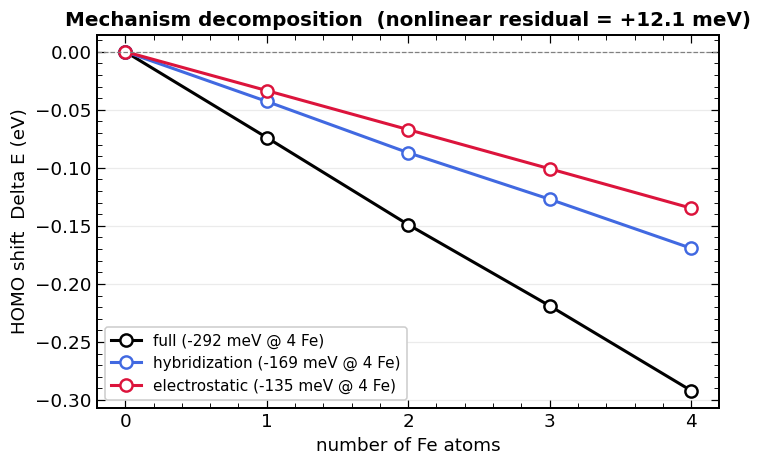

In [9]:
def plot_effect_decomposition(label='HOMO', params=None):
    cfg = [('full',            True,  True,  'black'),
           ('hybridization',   True,  False, 'royalblue'),
           ('electrostatic',   False, True,  'crimson')]
    rows = {}
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    for name, hyb, ele, color in cfg:
        rs = track_reference_orbital(label, params=params,
                                     include_hybridization=hyb,
                                     include_electrostatics=ele)
        rows[name] = rs
        ax.plot([r['n_fe'] for r in rs], [r['shift_V'] for r in rs],
                'o-', lw=2, ms=8, color=color, mfc='white', mew=1.6,
                label=f'{name} ({rs[-1]["shift_V"]*1000:+.0f} meV @ 4 Fe)')

    nonlin = (rows['full'][-1]['shift_V']
              - rows['hybridization'][-1]['shift_V']
              - rows['electrostatic'][-1]['shift_V'])
    ax.axhline(0, color='0.5', lw=0.8, ls='--')
    ax.set_xticks(range(5))
    ax.set_xlabel('number of Fe atoms')
    ax.set_ylabel(f'{label.upper()} shift  Delta E (eV)')
    ax.set_title(f'Mechanism decomposition  (nonlinear residual = {nonlin*1000:+.1f} meV)')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(loc='lower left')
    origin_style(ax)
    plt.tight_layout()
    plt.show()
    return rows


effect_rows = plot_effect_decomposition('HOMO')


## 8. Energy levels vs |beta_CC| (beta sweep)

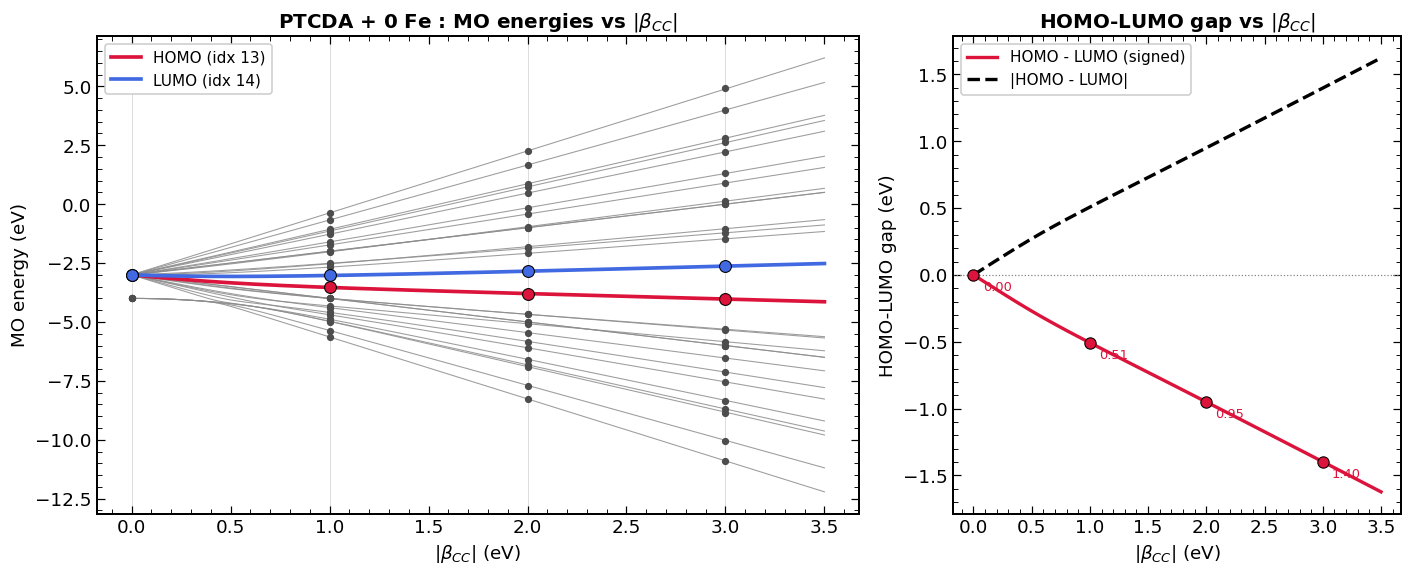

\n  |beta_CC|(eV)   HOMO(eV)    LUMO(eV)    HOMO-LUMO(eV)   |gap|(eV)
      0.0          -3.0000     -3.0000        +0.0000      0.0000
      1.0          -3.5355     -3.0270        -0.5085      0.5085
      2.0          -3.7964     -2.8439        -0.9525      0.9525
      3.0          -4.0295     -2.6288        -1.4007      1.4007


In [10]:
def beta_sweep_levels(beta_cc_values, n_fe=0, params=None):
    """Return (M, N) array of MO energies for each beta_cc value.

    beta_co_double and beta_fe_o are scaled with the same ratio as beta_cc / PARAMS['beta_cc']
    so the relative coupling pattern is preserved.
    """
    base = params_with(params)
    ratio_co = base['beta_co_double'] / base['beta_cc']
    ratio_fe = base['beta_fe_o']      / base['beta_cc']
    rows = []
    for b_cc in beta_cc_values:
        override = {
            'beta_cc':        b_cc,
            'beta_co_double': b_cc * ratio_co,
            'beta_fe_o':      b_cc * ratio_fe,
        }
        sol = solve_ptcda_fe(n_fe, params=override)
        rows.append(sol['energies'])
    return np.array(rows)


def plot_beta_sweep(n_fe=0, beta_max=3.5, n_points=160, params=None):
    """Plot all MO energies vs |beta_CC|, highlighting HOMO / LUMO and the gap."""
    beta_abs = np.linspace(0.0, beta_max, n_points)
    beta_cc_values = -beta_abs   # sign convention: beta_CC < 0
    E = beta_sweep_levels(beta_cc_values, n_fe=n_fe, params=params)

    fill = combined_filling(n_fe)
    homo_idx, lumo_idx = fill['homo'], fill['lumo']
    homo_track = E[:, homo_idx]
    lumo_track = E[:, lumo_idx]
    gap_signed = homo_track - lumo_track   # HOMO - LUMO (negative)
    gap_abs    = np.abs(gap_signed)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.4),
                                   gridspec_kw={'width_ratios': [1.7, 1.0]})

    # Left: all MO energy levels vs |beta|.
    for n in range(E.shape[1]):
        ax1.plot(beta_abs, E[:, n], color='0.55', lw=0.7, alpha=0.85)
    ax1.plot(beta_abs, homo_track, color='crimson',   lw=2.4,
             label=f'HOMO (idx {homo_idx})')
    ax1.plot(beta_abs, lumo_track, color='royalblue', lw=2.4,
             label=f'LUMO (idx {lumo_idx})')

    # Integer-beta annotations: scatter all levels + highlight HOMO/LUMO.
    marker_betas = np.arange(0, int(beta_max) + 1)
    for b in marker_betas:
        ax1.axvline(b, color='0.85', lw=0.6, zorder=0)
        idx = int(np.argmin(np.abs(beta_abs - b)))
        ax1.scatter([b] * E.shape[1], E[idx, :],
                    s=14, color='0.3', zorder=2)
        ax1.scatter([b], [E[idx, homo_idx]],
                    s=60, color='crimson',   edgecolor='k', lw=0.7, zorder=4)
        ax1.scatter([b], [E[idx, lumo_idx]],
                    s=60, color='royalblue', edgecolor='k', lw=0.7, zorder=4)

    ax1.set_xlabel(r'$|\beta_{CC}|$ (eV)')
    ax1.set_ylabel('MO energy (eV)')
    ax1.set_title(rf'PTCDA + {n_fe} Fe : MO energies vs $|\beta_{{CC}}|$')
    ax1.legend(loc='best')
    origin_style(ax1)

    # Right: HOMO-LUMO gap evolution.
    ax2.plot(beta_abs, gap_signed, color='crimson', lw=2.2,
             label='HOMO - LUMO (signed)')
    ax2.plot(beta_abs, gap_abs,    color='black',  lw=2.2, ls='--',
             label='|HOMO - LUMO|')
    for b in marker_betas:
        idx = int(np.argmin(np.abs(beta_abs - b)))
        g = gap_signed[idx]
        ax2.scatter([b], [g], s=55, color='crimson', edgecolor='k', lw=0.7, zorder=4)
        ax2.annotate(f'{abs(g):.2f}', (b, g),
                     textcoords='offset points', xytext=(6, -10),
                     fontsize=8.5, color='crimson')
    ax2.axhline(0, color='0.5', lw=0.8, ls=':')
    ax2.set_xlabel(r'$|\beta_{CC}|$ (eV)')
    ax2.set_ylabel('HOMO-LUMO gap (eV)')
    ax2.set_title(r'HOMO-LUMO gap vs $|\beta_{CC}|$')
    ax2.legend(loc='best')
    origin_style(ax2)
    plt.tight_layout()
    plt.show()

    # Integer-beta summary table.
    print(f'\\n  |beta_CC|(eV)   HOMO(eV)    LUMO(eV)    HOMO-LUMO(eV)   |gap|(eV)')
    for b in marker_betas:
        idx = int(np.argmin(np.abs(beta_abs - b)))
        print(f'   {b:>6.1f}        {homo_track[idx]:>+9.4f}   {lumo_track[idx]:>+9.4f}'
              f'   {gap_signed[idx]:>+12.4f}    {gap_abs[idx]:>8.4f}')
    return {'beta_abs': beta_abs, 'E_all': E,
            'homo': homo_track, 'lumo': lumo_track,
            'gap_signed': gap_signed, 'gap_abs': gap_abs}


beta_sweep_result = plot_beta_sweep(n_fe=0, beta_max=3.5, n_points=200)
